# Cognitive & Behavioral Predictors of Student Outcomes

**Group Members:** Mohammad Zoraiz (mz248), Rithik Duvva (rrd18), Kartikeye Gupta (kg330), Ratish Korrapati (rsk49), Enoch Li (yel6)  
**Course:** CS216 Everything Data (Spring 2026)  
**Date:** Feb 19, 2026  
**Repo:** [CampusSignals](https://github.com/zoraizmohammad/CampusSignals)  

## AI Disclosure
Artificial Intelligence Tools: ChatGPT (OpenAI, ChatGPT Edu via Duke University, accessed Jan–Feb 2026)  
- Conceptualization: refined and narrowed research questions.  
- Information collection: located documented, non-synthetic datasets and documentation.  
- Methodology support: suggested mediation-style analysis + supervised ML with ablation testing.  
- Writing/review/editing: improved structure and clarity.

---

## Research Questions
1. How do screen-use patterns (including type), sleep characteristics, and behavioral indicators relate to academic outcomes (grades/GPA proxies)?
2. To what extent do sleep characteristics mediate the relationship between screen use and academic outcomes?
3. Can we predict student outcomes from behavioral and sleep-related features, and which feature groups contribute most?

---

## Modules (mapped to this notebook)
- **Visualization (Module 3):** distributions, relationships, stratified plots, model diagnostics.
- **Data Wrangling (Module 4):** missingness handling, encoding, feature engineering.
- **Statistical Inference (Module 7):** multivariable regression + mediation-style inference with uncertainty.
- **Prediction & Supervised ML (Module 8):** cross-validation, ablations, and interpretability/feature importance.

---

## Notebook Output
This notebook runs the same analysis workflow independently on:
- **Dataset A:** `datasets/mendeley/repositorio.xlsx` (adolescents; screen use, sleep, daytime sleepiness, grades)
- **Dataset B:** `datasets/student-life/` (college students; passive sensing + sleep/stress + academic performance)

Then it compares results across cohorts (directionality + predictive performance).

---

## Plan of Attack (sections)
- Dataset A: ingestion -> schema validation -> feature engineering -> EDA -> mediation -> prediction -> ablations
- Dataset B: ingestion -> cohort outcome assembly -> feature engineering (including keyword-based app categories) -> EDA -> mediation -> prediction -> ablations
- Cross-cohort comparison, robustness, and final reproducibility cleanup


## Dataset A (Adolescents)

### A.1 Ingestion & Schema Validation
- Read `datasets/mendeley/repositorio.xlsx`
- Identify columns for screen-use (weekday/weekend, before bedtime), sleep metrics, daytime sleepiness/PDSS, and grades/GPA

### A.2 Wrangling & Feature Engineering
- Clean missingness
- Engineer screen-use features + sleep features
- Create outcome target: averaged GPA proxy = mean(`DI1 lengua`, `DJ1 matematica`)

### A.3 EDA & Visualization
- Distributions, relationships, stratified comparisons

### A.4 Inference / Mediation-Style Workflow
- screen -> sleep -> academic outcome

### A.5 Prediction & Ablations (RQ3)
- Cross-validation prediction with feature-group ablations

---

## Dataset B (College Students)

### B.1 Ingestion (cohort outcome + sleepiness inputs)
- Load `datasets/student-life/dataset/education/grades.csv`
- Load sleepiness survey inputs (e.g., `datasets/student-life/dataset/survey/psqi.csv`)
- Load EMA “Sleep” JSONs (response folder)

### B.2 Feature Engineering
- Passive sensing aggregation into user-level features
- Keyword-based app-to-screen-category mapping (keyword rules defined in-notebook)

### B.3 EDA & Visualization
- Sanity checks and exploratory relationships

### B.4 Inference / Mediation-Style Workflow
- screen -> sleep -> academic outcome

### B.5 Prediction & Ablations (RQ3)
- Cross-validation prediction with feature-group ablations

---

## Cross-Cohort Comparison
- Compare effect directions and predictive performance between Dataset A and B
- Robustness checks + final limitations


In [3]:
import re
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd


def _colref_to_col_index(cell_ref: str) -> int:
    """Convert Excel cell ref like 'A1' or 'BC12' to 0-based column index."""
    letters = re.match(r"^[A-Z]+", cell_ref.upper()).group(0)
    idx = 0
    for ch in letters:
        idx = idx * 26 + (ord(ch) - ord('A') + 1)
    return idx - 1


def read_xlsx_first_sheet(xlsx_path: str | Path) -> pd.DataFrame:
    """Read the first sheet from an .xlsx using only ZIP/XML parsing.

    This avoids needing `openpyxl`/`xlrd` in the runtime.
    """
    xlsx_path = Path(xlsx_path)
    with zipfile.ZipFile(xlsx_path, 'r') as zf:
        # Shared strings are used for most cell values.
        shared_strings = {}
        if 'xl/sharedStrings.xml' in zf.namelist():
            shared_xml = zf.read('xl/sharedStrings.xml')
            shared_root = ET.fromstring(shared_xml)
            ns_ss = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
            for idx, si in enumerate(shared_root.findall('.//w:si', ns_ss)):
                parts = []
                for t in si.findall('.//w:t', ns_ss):
                    if t.text:
                        parts.append(t.text)
                shared_strings[idx] = ''.join(parts)

        # Find sheet target (sheet xml file) for the first sheet.
        workbook_xml = zf.read('xl/workbook.xml')
        workbook_root = ET.fromstring(workbook_xml)
        ns_wb = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

        sheets = []
        for sheet in workbook_root.findall('.//w:sheets/w:sheet', ns_wb):
            name = sheet.attrib.get('name')
            rid = sheet.attrib.get('{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id')
            sheets.append((name, rid))
        if not sheets:
            raise ValueError('No sheets found in workbook.xml')

        first_name, first_rid = sheets[0]

        rels_xml = zf.read('xl/_rels/workbook.xml.rels')
        rels_root = ET.fromstring(rels_xml)
        ns_rel = {'r': 'http://schemas.openxmlformats.org/package/2006/relationships'}
        relmap = {}
        for rel in rels_root.findall('.//r:Relationship', ns_rel):
            rid = rel.attrib.get('Id')
            target = rel.attrib.get('Target')
            relmap[rid] = target

        if first_rid not in relmap:
            raise KeyError(f'Could not resolve relationship id {first_rid}')

        target = relmap[first_rid]
        # Target should look like 'worksheets/sheet1.xml'
        if target.startswith('worksheets/'):
            sheet_xml_path = 'xl/' + target
        else:
            # Sometimes it's already fully qualified under xl/
            sheet_xml_path = target
            if not sheet_xml_path.startswith('xl/'):
                sheet_xml_path = 'xl/' + sheet_xml_path

        sheet_xml_bytes = zf.read(sheet_xml_path)
        sheet_root = ET.fromstring(sheet_xml_bytes)
        ns_sheet = {'w': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

        rows = sheet_root.findall('.//w:sheetData/w:row', ns_sheet)
        if not rows:
            raise ValueError('No rows found in sheetData')

        # Header row assumed to be first row.
        header_row = rows[0]
        header_cells = header_row.findall('w:c', ns_sheet)
        if not header_cells:
            raise ValueError('No header cells in first row')

        col_indices = []
        for c in header_cells:
            ref = c.attrib.get('r')
            if not ref:
                continue
            col_indices.append(_colref_to_col_index(ref))
        max_col = max(col_indices) + 1

        headers = [''] * max_col
        for c in header_cells:
            cell_ref = c.attrib.get('r', '')
            col_i = _colref_to_col_index(cell_ref)
            t = c.attrib.get('t')
            v = c.find('w:v', ns_sheet)
            if v is None or v.text is None:
                val = ''
            else:
                if t == 's':
                    val = shared_strings.get(int(v.text), '')
                else:
                    val = v.text
            headers[col_i] = (val or '').strip()

        def cell_value(c):
            t = c.attrib.get('t')
            v = c.find('w:v', ns_sheet)
            if v is None or v.text is None:
                return ''
            if t == 's':
                return shared_strings.get(int(v.text), '')
            return v.text

        data = []
        for row in rows[1:]:
            row_vals = [''] * max_col
            for c in row.findall('w:c', ns_sheet):
                ref = c.attrib.get('r')
                if not ref:
                    continue
                col_i = _colref_to_col_index(ref)
                row_vals[col_i] = cell_value(c)
            # Keep rows even if entirely empty; we’ll drop later.
            data.append(row_vals)

        df = pd.DataFrame(data, columns=headers)

        # Drop fully-empty columns/rows.
        df = df.replace(r'^\s*$', np.nan, regex=True)
        df = df.dropna(axis=1, how='all')
        df = df.dropna(axis=0, how='all')

        # Strip column names
        df.columns = [str(c).strip() for c in df.columns]

        print(f"Loaded sheet '{first_name}' with shape={df.shape}")
        return df


# -----------------------
# Dataset A ingestion
# -----------------------

a_path = Path('datasets/mendeley/repositorio.xlsx')
assert a_path.exists(), f"Missing {a_path}"

# Load raw spreadsheet (prefer cached CSV if present for speed)
cache_csv = Path('datasets/mendeley/repositorio.csv')
if cache_csv.exists():
    print(f"Loading cached Dataset A CSV from {cache_csv}")
    A_raw = pd.read_csv(cache_csv)
else:
    print("Loading Dataset A from XLSX (ZIP/XML parsing)")
    A_raw = read_xlsx_first_sheet(a_path)

# Quick schema validation + variable-group mapping
cols = set(map(str, A_raw.columns))

# Outcomes (per plan: lingua/matematica -> averaged GPA proxy)
outcome_cols = [c for c in ['lengua', 'matematica'] if c in cols]

# Daytime sleepiness / PDSS proxy
pdss_cols = [c for c in cols if c.lower().strip() == 'somno01pdss' or 'pdss' in c.lower()]

# Screen-use related columns (heuristics based on Spanish question/variable names)
screen_cols = sorted(
    [c for c in cols if re.search(r'pantalla|videojueg|redes|tvonline|tpotv|otras|tpopantallatotal', c, flags=re.I)]
)

# Sleep-related columns
sleep_cols = sorted(
    [c for c in cols if re.search(r'dorm|siesta|sueñ|acost|levant|tard|horasueñ|hora.*dorm|bedtime', c, flags=re.I)]
)

print("\nSchema validation")
print("- outcome_cols found:", outcome_cols)
print("- pdss_cols found:", pdss_cols)

missing = []
if len(outcome_cols) != 2:
    missing.append(f"outcomes missing: {set(['lengua','matematica']) - set(outcome_cols)}")
if len(pdss_cols) < 1:
    missing.append('somno01pdss / pdss column missing')

if missing:
    print("WARNING:")
    for m in missing:
        print("-", m)
else:
    print("All required outcome + PDSS columns are present.")

print("\nVariable-group mapping (sample of matched columns)")

def _print_group(title, columns, limit=25):
    preview = columns[:limit]
    print(f"- {title}: {preview}{' ...' if len(columns) > limit else ''} (n={len(columns)})")

# Screen categories (gaming/social/TV/other) via name prefixes.
cat_gaming = sorted([c for c in screen_cols if re.search(r'videojueg|juego|tpojueg', c, flags=re.I)])
cat_social = sorted([c for c in screen_cols if re.search(r'redes', c, flags=re.I)])
cat_tv = sorted([c for c in screen_cols if re.search(r'tvonline|tpotv|TV o Smart TV|smart', c, flags=re.I)])
cat_other = sorted([c for c in screen_cols if c not in set(cat_gaming + cat_social + cat_tv)])

_print_group('screen_cols (broad)', screen_cols)
_print_group('screen category - gaming', cat_gaming)
_print_group('screen category - social', cat_social)
_print_group('screen category - tv/video', cat_tv)
_print_group('screen category - other', cat_other)
_print_group('sleep_cols (heuristic)', sleep_cols)

print("\nA_raw.head()")
A_raw.head()


Loading cached Dataset A CSV from datasets/mendeley/repositorio.csv

Schema validation
- outcome_cols found: ['lengua', 'matematica']
- pdss_cols found: ['somno01pdss']
All required outcome + PDSS columns are present.

Variable-group mapping (sample of matched columns)
- screen_cols (broad): ['Otras actividades frente a una pantalla.', 'Uso de redes sociales (Facebook, Instagram, Twitter, Snapchat, etc).', 'Videojuegos en computadora o consolas (PlayStation, Xbox, WII, etc).', 'datoscompletoPANTALLAS', 'excSUENOpantallas', 'tpootrasPORC', 'tpootrashs', 'tpootrashstrimed', 'tpootrashstrimedCAT', 'tpopantallatotalhs', 'tpopantallatotalhscat', 'tpopantallatotalhscat2', 'tpopantallatotalhstrimmed', 'tporedesPORC', 'tporedeshs', 'tporedeshstrimmed', 'tporedeshstrimmed01', 'tporedeshstrimmedCAT', 'tpotvonlinePORC', 'tpotvonlinehs', 'tpotvonlinehstrimeed', 'tpotvonlinehstrimeed01', 'tpotvonlinehstrimeedCAT', 'tpovideojuegosPORC', 'tpovideojuegoshs'] ... (n=29)
- screen category - gaming: ['Vi

,Submission Date,Código,investigador,Colegio,Ciudad,grado,edad,Fecha de nacimiento,FECHA_NAC_RECOD,Sexo,...,matematica,prom,aplazos,datoscompletoDEMOG,datoscompletoSUENO,datoscompletoPANTALLAS,excSUENOpantallas,excluidos,missingnotas,excluFINAL
0,2019-06-14 09:44:31,01 01 01 1 1 AS 0 170407,1,1,1,1,NaN,4/21/07,Sin información,Femenino,...,NaN,NaN,NaN,0,0,0,1,1,1,1
1,2019-06-14 09:56:35,01 01 01 1 1 AS 1 240107,1,1,1,1,12.0,1/24/07,24/01/2007,Masculino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
2,2019-06-14 09:46:25,01 01 01 1 1 bk 1 151006,1,1,1,1,13.0,10/15/06,15/10/2006,Masculino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
3,2019-06-14 09:43:34,01 01 01 1 1 CG 0 051006,1,1,1,1,13.0,10/5/06,05/10/2006,Femenino,...,NaN,NaN,NaN,1,0,0,1,1,1,1
4,2019-06-14 09:54:51,01 01 01 1 1 EQ 1 230505,1,1,1,1,NaN,5/27/05,Sin información,Masculino,...,NaN,NaN,NaN,0,0,0,1,1,1,1


In [4]:
from pathlib import Path

# -----------------------
# Dataset A wrangling
# -----------------------

A_path = Path('datasets/mendeley/repositorio.csv')
assert A_path.exists(), f"Missing {A_path}"
A_raw = pd.read_csv(A_path)

# Normalize missing encodings and booleans
A = A_raw.replace({'FALSE': 0, 'TRUE': 1})
A = A.replace(r'^\s*$', np.nan, regex=True)

# Numeric conversions (we only convert columns we know are numeric-coded)
# Targets
for c in ['lengua', 'matematica', 'somno01pdss', 'problemasatencionrecod']:
    if c in A.columns:
        A[c] = pd.to_numeric(A[c], errors='coerce')

# Sleep duration: prefer processed weekday sleep hours if present
sleep_duration_candidates = ['horasueñosemanahr-proc', 'horasueñosemanahr']
sleep_duration_col = next((c for c in sleep_duration_candidates if c in A.columns), None)
assert sleep_duration_col is not None, "Could not find weekday sleep duration column"
A[sleep_duration_col] = pd.to_numeric(A[sleep_duration_col], errors='coerce')
A = A.rename(columns={sleep_duration_col: 'sleep_duration_hours'})

# Screen day-count features (frequency categories)
screen_day_cols = [
    'cantdiastv01',
    'cantdiascelular01',
    'cantdiascompus01',
    'cantdiasconsolajuegos01',
    'cantdiasconsolajuegoshstrimmed',
]
# The last item may not exist; filter to real columns.
# Also include tablet category if present.
optional_screen_cols = ['cantdiasconsolajuegostrimmed', 'cantdiascelulartrimmed', 'cantdiastablet01', 'cantdiascompustrimmed', 'cantdiasconsolajuegos01', 'cantdiastvtrimmed', 'cantdiasconsolajuegos01']

screen_day_cols = [c for c in screen_day_cols if c in A.columns]
# Add the canonical set we observed to exist in the exported CSV.
for c in ['cantdiastv01','cantdiastablet01','cantdiasconsolajuegos01','cantdiascompus01','cantdiascelular01']:
    if c in A.columns and c not in screen_day_cols:
        screen_day_cols.append(c)

# Bedtime indicators
bedtime_cols = [c for c in ['WATCHTVbedtime7D01','COMPUbedtime1D01','COMPUbedtime2D01'] if c in A.columns]
for c in bedtime_cols:
    A[c] = pd.to_numeric(A[c], errors='coerce')

# Outcome: GPA proxy as mean(language, math)
A['gpa_proxy'] = A[['lengua', 'matematica']].mean(axis=1, skipna=True)

# Behavioral indicator(s)
behavior_cols = [c for c in ['problemasatencionrecod'] if c in A.columns]

# Create simplified modeled groups
A_model_cols = (
    ['Código', 'gpa_proxy', 'sleep_duration_hours', 'somno01pdss']
    + screen_day_cols
    + bedtime_cols
    + behavior_cols
)

missing_cols = [c for c in A_model_cols if c not in A.columns]
if missing_cols:
    raise ValueError(f"Missing expected Dataset A columns: {missing_cols}")

A_model_df = A[A_model_cols].copy()
A_model_df = A_model_df.rename(columns={'somno01pdss': 'sleepiness_pdss'})

# Basic cleaning: keep rows with target available
A_model_df = A_model_df[~A_model_df['gpa_proxy'].isna()].copy()

# Missingness report for feature columns
feature_groups = {
    'screen': screen_day_cols + bedtime_cols,
    'sleep': ['sleep_duration_hours', 'sleepiness_pdss'],
    'behavior': behavior_cols,
}

print('Dataset A modeling table')
print('A_raw shape:', A_raw.shape)
print('A_model_df shape (rows with gpa_proxy):', A_model_df.shape)

for grp, cols in feature_groups.items():
    keep_cols = [c for c in cols if c in A_model_df.columns]
    miss_rate = {c: float(A_model_df[c].isna().mean()) for c in keep_cols}
    # print top missing
    top = sorted(miss_rate.items(), key=lambda x: x[1], reverse=True)[:8]
    print(f"\nGroup '{grp}'")
    print('  n_cols:', len(keep_cols))
    for c, r in top:
        print(f"  {c}: missing_rate={r:.3f}")

print('\nQuick summary of key variables')
print(A_model_df[['gpa_proxy','sleep_duration_hours','sleepiness_pdss']].describe())

# Convenience variables for later notebook sections
A_targets = ['gpa_proxy']
A_mediator_cols = ['sleepiness_pdss']
A_sleep_covariates = ['sleep_duration_hours']
A_screen_features = screen_day_cols + bedtime_cols
A_behavior_features = behavior_cols


Dataset A modeling table
A_raw shape: (4115, 123)
A_model_df shape (rows with gpa_proxy): (1261, 13)

Group 'screen'
  n_cols: 8
  cantdiastv01: missing_rate=0.000
  cantdiascelular01: missing_rate=0.000
  cantdiascompus01: missing_rate=0.000
  cantdiasconsolajuegos01: missing_rate=0.000
  cantdiastablet01: missing_rate=0.000
  WATCHTVbedtime7D01: missing_rate=0.000
  COMPUbedtime1D01: missing_rate=0.000
  COMPUbedtime2D01: missing_rate=0.000

Group 'sleep'
  n_cols: 2
  sleep_duration_hours: missing_rate=0.145
  sleepiness_pdss: missing_rate=0.000

Group 'behavior'
  n_cols: 1
  problemasatencionrecod: missing_rate=0.000

Quick summary of key variables
         gpa_proxy  sleep_duration_hours  sleepiness_pdss
count  1261.000000           1078.000000      1261.000000
mean      7.306614             21.419295         0.727994
std       1.438960              3.663920         0.445170
min       2.000000             13.500000         0.000000
25%       6.500000             21.500000        

## A.3 EDA & Visualization (Dataset A)

Plots and summary tables for:
- Outcome: `gpa_proxy`
- Sleep: `sleep_duration_hours`
- Daytime sleepiness mediator: `sleepiness_pdss`
- Screen-use features: device-day counts (`cantdias*01`) + bedtime indicators
- Behavioral proxy: `problemasatencionrecod`


EDA inputs
  screen_cols: ['cantdiastv01', 'cantdiascelular01', 'cantdiascompus01', 'cantdiasconsolajuegos01', 'cantdiastablet01', 'WATCHTVbedtime7D01', 'COMPUbedtime1D01', 'COMPUbedtime2D01']
  sleep_cols: ['sleep_duration_hours']
  behavior_cols: ['problemasatencionrecod']

Missingness (top) on available columns
sleep_duration_hours       0.145123
gpa_proxy                  0.000000
sleepiness_pdss            0.000000
cantdiastv01               0.000000
cantdiascelular01          0.000000
cantdiascompus01           0.000000
cantdiasconsolajuegos01    0.000000
cantdiastablet01           0.000000
WATCHTVbedtime7D01         0.000000
COMPUbedtime1D01           0.000000
dtype: float64

Group means by sleepiness_pdss
                 gpa_proxy  sleep_duration_hours
sleepiness_pdss                                 
0                 7.407638             21.889262
1                 7.268867             21.239744

Group means by screen_any (if available)
            gpa_proxy  sleep_duration_h

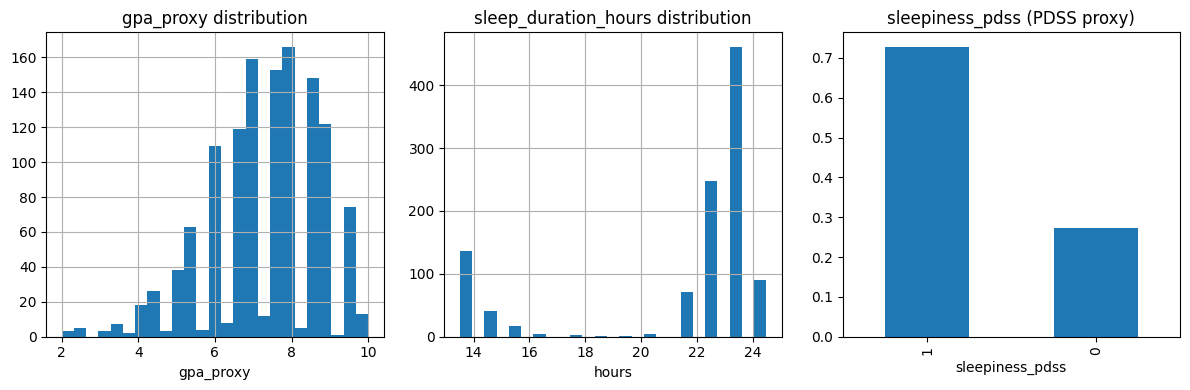

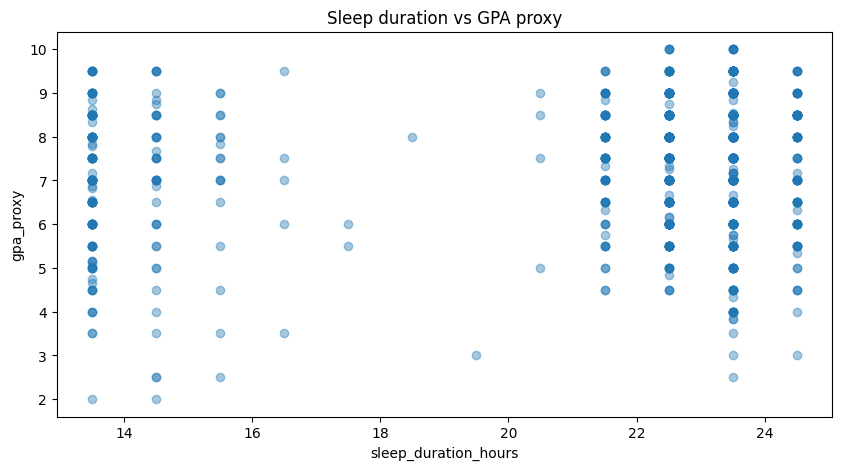

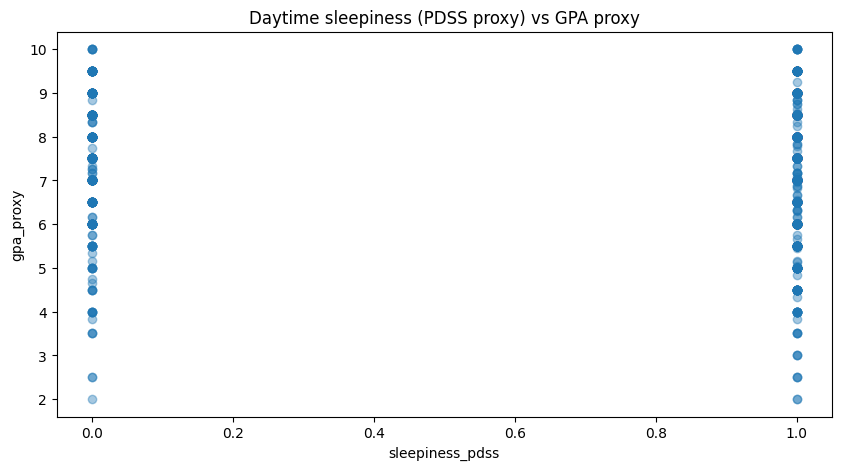

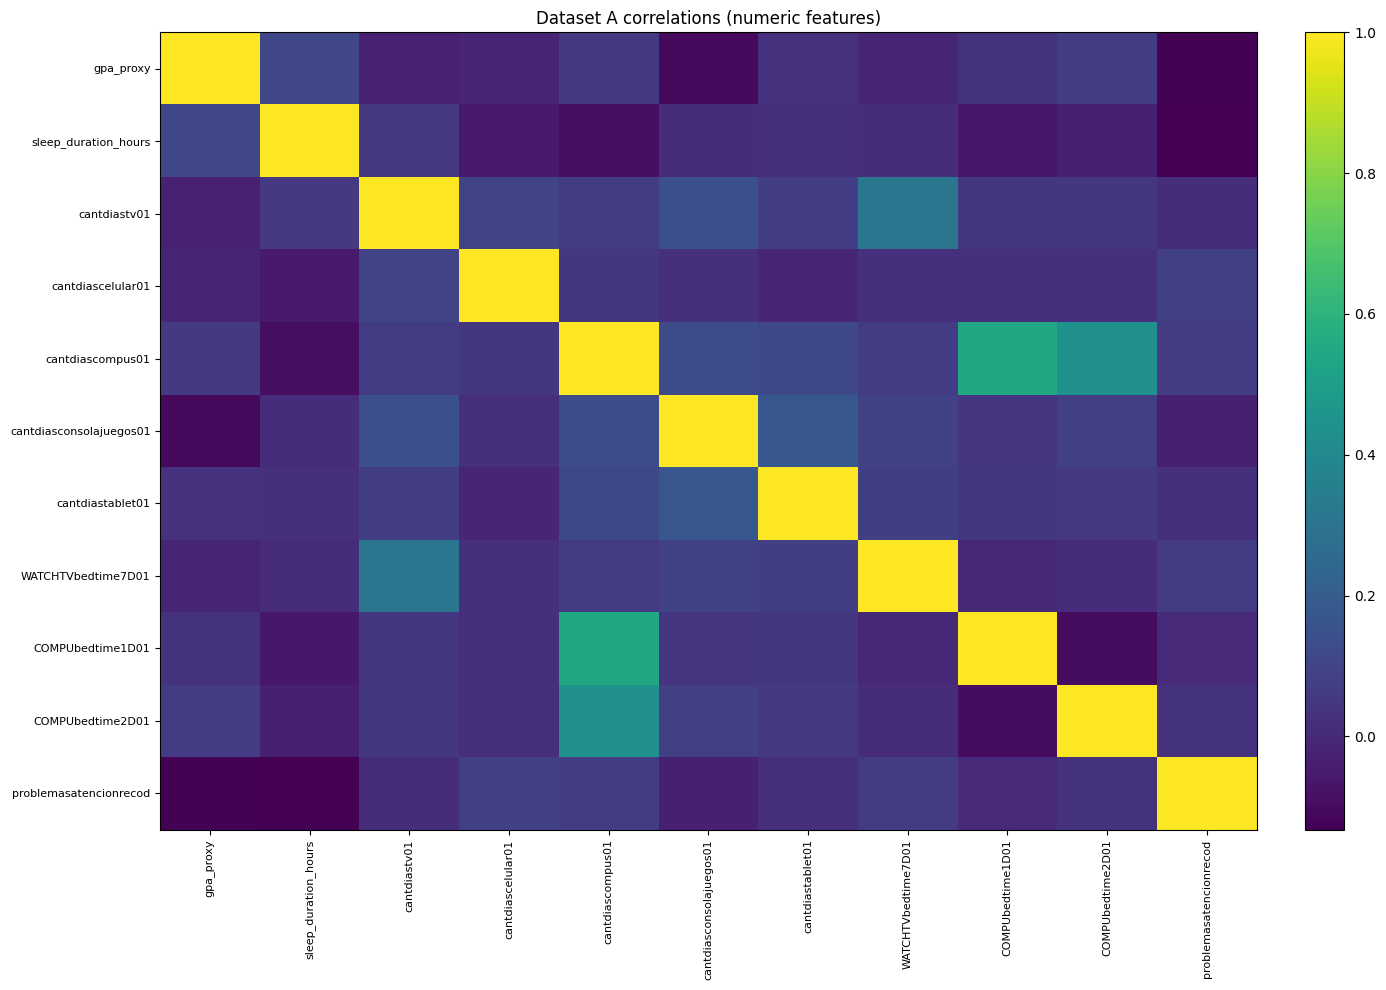

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=[str(k) for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())])


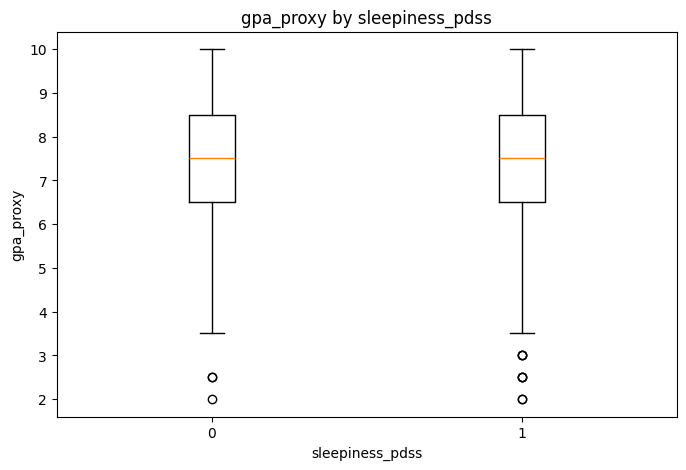

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


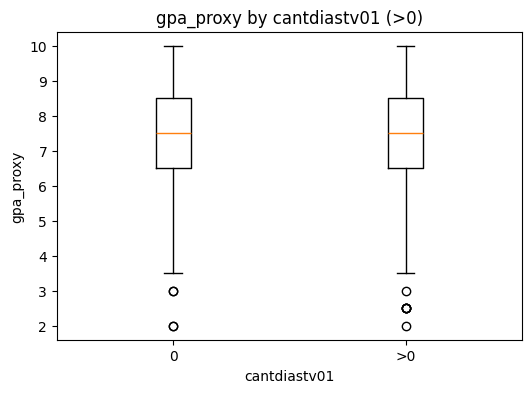

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


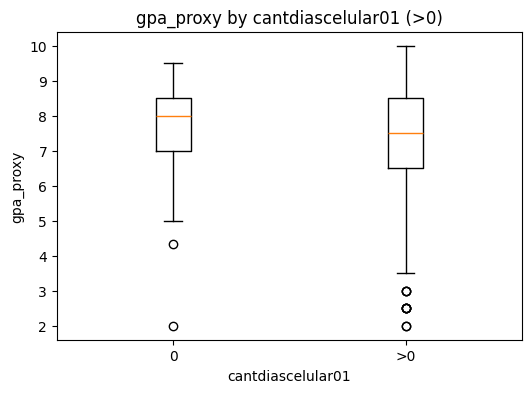

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


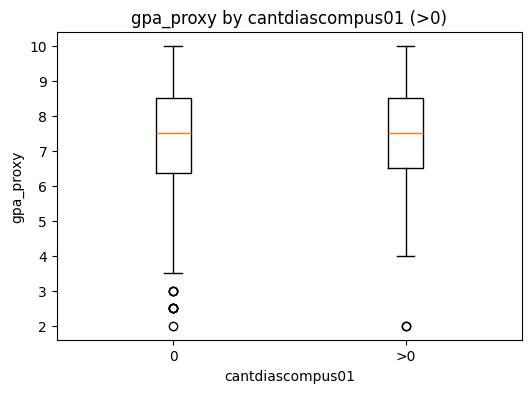

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


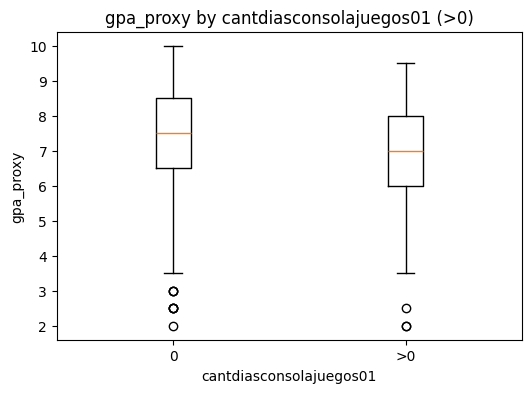

/var/folders/zr/5crywxy91hl91sm9xrmd03kc0000gn/T/ipykernel_98052/1041541882.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=['0','>0'])


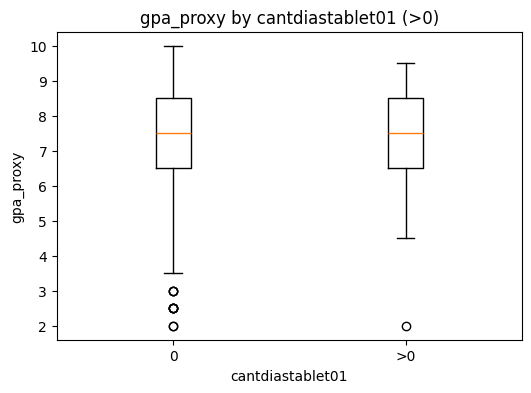

EDA complete for Dataset A


In [5]:
import matplotlib.pyplot as plt

# Guard: ensure wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

# Feature lists (from Dataset A wrangling)
screen_cols = [c for c in globals().get('A_screen_features', []) if c in A_model_df.columns]
sleep_cols = [c for c in globals().get('A_sleep_covariates', []) if c in A_model_df.columns]
behavior_cols = [c for c in globals().get('A_behavior_features', []) if c in A_model_df.columns]

print('EDA inputs')
print('  screen_cols:', screen_cols)
print('  sleep_cols:', sleep_cols)
print('  behavior_cols:', behavior_cols)

# -----------------------
# Summary tables
# -----------------------
summary_cols = ['gpa_proxy', 'sleep_duration_hours', 'sleepiness_pdss'] + screen_cols + behavior_cols
available_summary_cols = [c for c in summary_cols if c in A_model_df.columns]

print("\nMissingness (top) on available columns")
miss = A_model_df[available_summary_cols].isna().mean().sort_values(ascending=False)
print(miss.head(10))

print("\nGroup means by sleepiness_pdss")
group_sleep = A_model_df.groupby('sleepiness_pdss')[[
    'gpa_proxy', 'sleep_duration_hours'
]].mean(numeric_only=True)
print(group_sleep)

print("\nGroup means by screen_any (if available)")
# Define a simple screen_any proxy from day-count features if possible
screen_day_features = [c for c in screen_cols if c.startswith('cantdias')]
if screen_day_features:
    A_model_df['screen_any'] = (A_model_df[screen_day_features].fillna(0).sum(axis=1) > 0).astype(int)
    print(A_model_df.groupby('screen_any')[['gpa_proxy','sleep_duration_hours','sleepiness_pdss']].mean(numeric_only=True))
else:
    print('No screen day-count columns available; skipping screen_any.')

# -----------------------
# Distributions
# -----------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
A_model_df['gpa_proxy'].hist(bins=25)
plt.title('gpa_proxy distribution')
plt.xlabel('gpa_proxy')

plt.subplot(1, 3, 2)
A_model_df['sleep_duration_hours'].hist(bins=25)
plt.title('sleep_duration_hours distribution')
plt.xlabel('hours')

plt.subplot(1, 3, 3)
A_model_df['sleepiness_pdss'].value_counts(normalize=True).plot(kind='bar')
plt.title('sleepiness_pdss (PDSS proxy)')
plt.xlabel('sleepiness_pdss')

plt.tight_layout()
plt.show()

# -----------------------
# Relationship plots
# -----------------------
plt.figure(figsize=(10, 5))
plt.scatter(A_model_df['sleep_duration_hours'], A_model_df['gpa_proxy'], alpha=0.4)
plt.title('Sleep duration vs GPA proxy')
plt.xlabel('sleep_duration_hours')
plt.ylabel('gpa_proxy')
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(A_model_df['sleepiness_pdss'], A_model_df['gpa_proxy'], alpha=0.4)
plt.title('Daytime sleepiness (PDSS proxy) vs GPA proxy')
plt.xlabel('sleepiness_pdss')
plt.ylabel('gpa_proxy')
plt.show()

# -----------------------
# Correlation heatmap
# -----------------------
# Keep only numeric columns for correlations
corr_feature_candidates = ['gpa_proxy'] + sleep_cols + screen_cols + behavior_cols
corr_feature_candidates = [c for c in corr_feature_candidates if c in A_model_df.columns]

corr_df = A_model_df[corr_feature_candidates].copy()
# Convert constant columns to NaN correlations
corr = corr_df.corr(numeric_only=True)

# Drop rows/cols that are entirely NaN (e.g., constants)
mask_all_nan = corr.isna().all(axis=1) | corr.isna().all(axis=0)
if mask_all_nan.any():
    corr = corr.loc[~mask_all_nan, ~mask_all_nan]

plt.figure(figsize=(14, 10))
plt.imshow(corr.values, aspect='auto', interpolation='nearest')
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.title('Dataset A correlations (numeric features)')
plt.tight_layout()
plt.show()

# -----------------------
# Stratified comparisons
# -----------------------
# Boxplot GPA by sleepiness
plt.figure(figsize=(8, 5))
vals = [A_model_df.loc[A_model_df['sleepiness_pdss'] == k, 'gpa_proxy'] for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())]
plt.boxplot(vals, labels=[str(k) for k in sorted(A_model_df['sleepiness_pdss'].dropna().unique())])
plt.title('gpa_proxy by sleepiness_pdss')
plt.xlabel('sleepiness_pdss')
plt.ylabel('gpa_proxy')
plt.show()

# Boxplot GPA by each screen day-count (binarized)
for c in screen_day_features[:5]:
    # Convert to binary (any usage days)
    tmp = (A_model_df[c].fillna(0) > 0).astype(int)
    plt.figure(figsize=(6, 4))
    vals = [A_model_df.loc[tmp == k, 'gpa_proxy'] for k in [0,1]]
    plt.boxplot(vals, labels=['0','>0'])
    plt.title(f'gpa_proxy by {c} (>0)')
    plt.xlabel(c)
    plt.ylabel('gpa_proxy')
    plt.show()

print('EDA complete for Dataset A')


## A.4 Inference / Mediation-Style Workflow (Dataset A)

### Goal
Estimate whether **screen-use patterns** (exposure `X`) are associated with the academic outcome (**`gpa_proxy`**, outcome `Y`), and whether that relationship is **mediated by sleep characteristics** (mediator `M`).

This implements a **mediation-style linear workflow** using multivariable regression and reports uncertainty via both:
- **Bootstrap CIs** for path coefficients and indirect effects
- **Permutation testing** (randomized exposure) to gauge how unusual the indirect effect is under a null association structure

### Model (linear mediation-style)
For a chosen mediator `M` (sleep feature):

1. **Mediator model**:  `M = a * X + Cov + e`
2. **Outcome model**:   `Y = c' * X + b * M + Cov + u`

Derived effects:
- **Direct effect**: `c'`
- **Total effect**: `c` (from `Y = c * X + Cov`)
- **Indirect (mediated) effect**: `a*b`

### What we use as `X`, `M`, and covariates
- `X` (screen exposure) is a **composite index** built from Dataset A screen-use features (`A_screen_features`) and standardized to **1 SD** within the analysis sample.
- We run mediation **separately** for two sleep constructs:
  - Mediator 1: `sleepiness_pdss`, controlling for `sleep_duration_hours`
  - Mediator 2: `sleep_duration_hours`, controlling for `sleepiness_pdss`
- Optional covariate(s): Dataset A behavioral proxy `problemasatencionrecod` when available.

### Diagnostics included in the code cell
- Residual plots and Q-Q plots for mediator + outcome regressions
- Multicollinearity check via **VIF** for predictors in the outcome model

### Interpretation checklist (read after running)
- If the **bootstrap CI** for the indirect effect `a*b` excludes 0, that supports a mediated *association* between screen-use and GPA via sleep.
- The **permutation p-value** summarizes how often a similarly large indirect effect occurs under a randomized exposure null.
- Because the dataset is effectively cross-sectional/self-report, interpret results as **mediation-style evidence**, not definitive causal mediation, unless assumptions about timing and confounding are satisfied.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels is preferred; if unavailable, fall back to a lightweight numpy-based OLS
try:
    import statsmodels.api as sm  # type: ignore
except ModuleNotFoundError:
    from scipy import stats as _scipy_stats

    def _add_constant(X, has_constant: str = 'add'):
        """Minimal replacement for statsmodels.api.add_constant."""
        if isinstance(X, pd.DataFrame):
            if 'const' in X.columns:
                return X
            out = X.copy()
            out.insert(0, 'const', 1.0)
            return out
        X_arr = np.asarray(X, dtype=float)
        ones = np.ones((X_arr.shape[0], 1), dtype=float)
        return np.hstack([ones, X_arr])

    class _OLSResult:
        def __init__(self, params, fittedvalues, resid, rsquared):
            self.params = params
            self.fittedvalues = fittedvalues
            self.resid = resid
            self.rsquared = rsquared

    class _OLSModel:
        def __init__(self, endog, exog):
            self.endog = np.asarray(endog, dtype=float)
            self.exog_is_df = isinstance(exog, pd.DataFrame)
            self.exog_df = exog if self.exog_is_df else None
            self.exog_mat = exog.values.astype(float) if self.exog_is_df else np.asarray(exog, dtype=float)
            self.param_names = list(self.exog_df.columns) if self.exog_is_df else None

        def fit(self):
            beta = np.linalg.lstsq(self.exog_mat, self.endog, rcond=None)[0]
            fitted = self.exog_mat @ beta
            resid = self.endog - fitted
            ss_res = float(np.sum(resid ** 2))
            y = self.endog
            ss_tot = float(np.sum((y - y.mean()) ** 2))
            rsq = (1.0 - ss_res / ss_tot) if ss_tot != 0 else 0.0
            params = pd.Series(beta, index=self.param_names) if self.param_names is not None else beta
            return _OLSResult(params=params, fittedvalues=fitted, resid=resid, rsquared=rsq)

    def _OLS(endog, exog):
        return _OLSModel(endog=endog, exog=exog)

    def _qqplot(x, line: str = '45', ax=None):
        if ax is None:
            ax = plt.gca()
        _scipy_stats.probplot(x, dist='norm', plot=ax)
        return ax

    class _SMWrapper:
        add_constant = staticmethod(_add_constant)
        OLS = staticmethod(_OLS)
        qqplot = staticmethod(_qqplot)

    sm = _SMWrapper()

# -----------------------
# Parameters (adjust if runtime is too slow)
# -----------------------
N_BOOT = 300
N_PERM = 100
SEED = 42

# Guard: ensure wrangling ran
if 'A_model_df' not in globals():
    raise RuntimeError("A_model_df not found. Run Dataset A wrangling cell first.")

# -----------------------
# Exposure / feature definitions
# -----------------------
Y_COL = 'gpa_proxy'

screen_features = [c for c in globals().get('A_screen_features', []) if c in A_model_df.columns]
if not screen_features:
    raise RuntimeError("No screen features found in globals(). Expected A_screen_features from Dataset A wrangling.")

behavior_features = [c for c in globals().get('A_behavior_features', []) if c in A_model_df.columns]

BASE_DF = A_model_df.copy()

# Screen exposure composite (sum across features); missing screen values are treated as 0.
BASE_DF['screen_exposure_raw'] = BASE_DF[screen_features].fillna(0).sum(axis=1)

# Optional covariate(s)
COV_BASE = []
for c in behavior_features:
    if c not in COV_BASE:
        COV_BASE.append(c)

# Two sleep mediators; we run them separately for interpretability.
MEDIATOR_SPECS = [
    ('sleepiness_pdss', 'sleep_duration_hours'),  # M, covariate
    ('sleep_duration_hours', 'sleepiness_pdss'),  # M, covariate
]


def _standardize_1sd(x: pd.Series) -> pd.Series:
    """Standardize to mean=0, sd=1 (within a given analysis sample)."""
    x = pd.to_numeric(x, errors='coerce')
    sd = x.std(ddof=0)
    if sd is None or sd == 0 or np.isnan(sd):
        return x * 0.0
    return (x - x.mean()) / sd


def _fit_ols_models(df_work: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    """Fit: M~X+Cov and Y~X+M+Cov (X is standardized internally)."""
    df_work = df_work.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()

    # Standardize X within the (already complete-case) analysis sample
    df_work['X_std'] = _standardize_1sd(df_work['screen_exposure_raw'])

    y = df_work[Y_COL].astype(float).values
    m = df_work[mediator_col].astype(float).values

    # Mediator model: M ~ X + Cov
    X_m = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_work[c].values
    X_m = sm.add_constant(X_m, has_constant='add')
    model_m = sm.OLS(m, X_m).fit()
    a = float(model_m.params['x'])

    # Outcome model: Y ~ X + M + Cov
    X_y = pd.DataFrame({'x': df_work['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_work[c].values
    X_y = sm.add_constant(X_y, has_constant='add')
    model_y = sm.OLS(y, X_y).fit()
    b = float(model_y.params['m'])
    c_prime = float(model_y.params['x'])

    # Total effect model: Y ~ X + Cov
    X_t = pd.DataFrame({'x': df_work['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_work[c].values
    X_t = sm.add_constant(X_t, has_constant='add')
    model_t = sm.OLS(y, X_t).fit()
    c_total = float(model_t.params['x'])

    indirect = a * b

    return {
        'n': int(df_work.shape[0]),
        'a': a,
        'b': b,
        'c_prime': c_prime,
        'c_total': c_total,
        'indirect': indirect,
        'model_m': model_m,
        'model_y': model_y,
        'model_t': model_t,
        'df_work': df_work,
    }


def _vif(df_design: pd.DataFrame) -> pd.Series:
    """Variance Inflation Factor for numeric predictors (no constant required)."""
    # df_design: columns are predictors
    from numpy.linalg import LinAlgError

    vifs = {}
    for col in df_design.columns:
        y = df_design[col].astype(float).values
        X = df_design.drop(columns=[col]).astype(float)
        if X.shape[1] == 0:
            vifs[col] = np.nan
            continue
        try:
            r2 = sm.OLS(y, sm.add_constant(X, has_constant='add')).fit().rsquared
            vifs[col] = float(1.0 / (1.0 - r2)) if (1.0 - r2) != 0 else np.inf
        except LinAlgError:
            vifs[col] = np.inf
    return pd.Series(vifs)


def _compute_effects(df_sample: pd.DataFrame, mediator_col: str, cov_cols: list[str]):
    """Compute (a, b, c_prime, c_total, indirect) for one dataset draw."""
    df_sample = df_sample.dropna(subset=[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols).copy()
    if df_sample.shape[0] < 30:
        return None

    df_sample['X_std'] = _standardize_1sd(df_sample['screen_exposure_raw'])

    y = df_sample[Y_COL].astype(float).values
    m = df_sample[mediator_col].astype(float).values

    # M ~ X + Cov
    X_m = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_m[c] = df_sample[c].values
    X_m = sm.add_constant(X_m, has_constant='add')
    model_m = sm.OLS(m, X_m).fit()
    a = float(model_m.params['x'])

    # Y ~ X + M + Cov
    X_y = pd.DataFrame({'x': df_sample['X_std'].values, 'm': m})
    for c in cov_cols:
        X_y[c] = df_sample[c].values
    X_y = sm.add_constant(X_y, has_constant='add')
    model_y = sm.OLS(y, X_y).fit()
    b = float(model_y.params['m'])
    c_prime = float(model_y.params['x'])

    # Y ~ X + Cov
    X_t = pd.DataFrame({'x': df_sample['X_std'].values})
    for c in cov_cols:
        X_t[c] = df_sample[c].values
    X_t = sm.add_constant(X_t, has_constant='add')
    model_t = sm.OLS(y, X_t).fit()
    c_total = float(model_t.params['x'])

    indirect = a * b

    return a, b, c_prime, c_total, indirect


rng = np.random.default_rng(SEED)
results_rows = []

for mediator_col, other_sleep_cov in MEDIATOR_SPECS:
    if mediator_col not in BASE_DF.columns:
        print(f"Skipping mediator '{mediator_col}': missing column")
        continue

    cov_cols = list(COV_BASE)
    if other_sleep_cov in BASE_DF.columns:
        # Include the other sleep construct as a covariate so we can interpret M separately.
        cov_cols = cov_cols + [other_sleep_cov]

    # Complete-case base for this mediation run
    base_df = BASE_DF[[Y_COL, mediator_col, 'screen_exposure_raw'] + cov_cols].dropna().copy()
    n = int(base_df.shape[0])
    if n < 100:
        print(f"WARNING: mediation run for mediator='{mediator_col}' has small n={n} complete cases.")

    # Observed fits + diagnostics
    observed = _fit_ols_models(base_df, mediator_col=mediator_col, cov_cols=cov_cols)

    # VIF on outcome-model predictors (X_std, M, plus Cov)
    dfv = observed['df_work'].copy()
    dfv['X_std'] = _standardize_1sd(dfv['screen_exposure_raw'])
    design_out = pd.DataFrame({'X_std': dfv['X_std'].values, 'M': dfv[mediator_col].astype(float).values})
    for c in cov_cols:
        design_out[c] = dfv[c].values
    vif = _vif(design_out)

    print("\n" + "="*80)
    print(f"Dataset A mediation run: M='{mediator_col}', Cov={cov_cols}")
    print(f"Complete-case n={observed['n']}")
    print(f"Path estimates: a (X->M)={observed['a']:.4f}, b (M->Y|X)={observed['b']:.4f}")
    print(f"Effects: indirect=a*b={observed['indirect']:.4f}, direct c'={observed['c_prime']:.4f}, total c={observed['c_total']:.4f}")
    print("VIF (outcome model predictors):")
    print(vif.sort_values(ascending=False).to_string())

    # Bootstrap uncertainty
    boot_effects = []
    boot_indirect = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        sample_df = base_df.iloc[idx]
        eff = _compute_effects(sample_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        a, b, c_prime, c_total, indirect = eff
        boot_effects.append((a, b, c_prime, c_total, indirect))
        boot_indirect.append(indirect)

    boot_effects = np.array(boot_effects, dtype=float)
    if boot_effects.shape[0] < max(50, N_BOOT * 0.5):
        print(f"WARNING: bootstrap draws succeeded={boot_effects.shape[0]} / {N_BOOT} for mediator='{mediator_col}'")

    def _ci(x: np.ndarray, alpha: float = 0.05):
        lo = np.nanpercentile(x, 100 * (alpha/2))
        hi = np.nanpercentile(x, 100 * (1 - alpha/2))
        return float(lo), float(hi)

    a_boot = boot_effects[:, 0]
    b_boot = boot_effects[:, 1]
    c_prime_boot = boot_effects[:, 2]
    c_total_boot = boot_effects[:, 3]
    indirect_boot = boot_effects[:, 4]

    a_ci = _ci(a_boot)
    b_ci = _ci(b_boot)
    c_prime_ci = _ci(c_prime_boot)
    c_total_ci = _ci(c_total_boot)
    indirect_ci = _ci(indirect_boot)

    # Permutation null for indirect effect
    perm_indirect = []
    x_values = base_df['screen_exposure_raw'].astype(float).values
    for _ in range(N_PERM):
        perm_x = rng.permutation(x_values)
        perm_df = base_df.copy()
        perm_df['screen_exposure_raw'] = perm_x
        eff = _compute_effects(perm_df, mediator_col=mediator_col, cov_cols=cov_cols)
        if eff is None:
            continue
        perm_indirect.append(eff[-1])

    perm_indirect = np.array(perm_indirect, dtype=float)
    # Two-sided permutation p-value using absolute magnitude
    p_perm = (np.sum(np.abs(perm_indirect) >= abs(observed['indirect'])) + 1) / (len(perm_indirect) + 1)

    results_rows.append({
        'mediator': mediator_col,
        'n_complete_cases': observed['n'],
        'a_hat': observed['a'],
        'a_ci_low': a_ci[0],
        'a_ci_high': a_ci[1],
        'b_hat': observed['b'],
        'b_ci_low': b_ci[0],
        'b_ci_high': b_ci[1],
        'c_prime_hat': observed['c_prime'],
        'c_prime_ci_low': c_prime_ci[0],
        'c_prime_ci_high': c_prime_ci[1],
        'c_total_hat': observed['c_total'],
        'c_total_ci_low': c_total_ci[0],
        'c_total_ci_high': c_total_ci[1],
        'indirect_hat': observed['indirect'],
        'indirect_ci_low': indirect_ci[0],
        'indirect_ci_high': indirect_ci[1],
        'perm_p_value': p_perm,
        'boot_succ': int(boot_effects.shape[0]),
        'perm_succ': int(perm_indirect.shape[0]),
        'covariates_in_models': ','.join(cov_cols),
    })

    # -----------------------
    # Diagnostics plots (observed sample)
    # -----------------------
    model_m = observed['model_m']
    model_y = observed['model_y']

    # Mediator residuals
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # Residuals vs fitted (mediator)
    axes[0, 0].scatter(model_m.fittedvalues, model_m.resid, alpha=0.35)
    axes[0, 0].axhline(0, color='red', linewidth=1)
    axes[0, 0].set_title(f"Mediator residuals vs fitted\nM={mediator_col}")
    axes[0, 0].set_xlabel('Fitted')
    axes[0, 0].set_ylabel('Residuals')

    # Residuals vs fitted (outcome)
    axes[0, 1].scatter(model_y.fittedvalues, model_y.resid, alpha=0.35)
    axes[0, 1].axhline(0, color='red', linewidth=1)
    axes[0, 1].set_title(f"Outcome residuals vs fitted\nY=gpa_proxy")
    axes[0, 1].set_xlabel('Fitted')
    axes[0, 1].set_ylabel('Residuals')

    # Q-Q plot (mediator residuals)
    sm.qqplot(model_m.resid, line='45', ax=axes[1, 0])
    axes[1, 0].set_title(f"Q-Q plot (mediator residuals)\nM={mediator_col}")

    # Q-Q plot (outcome residuals)
    sm.qqplot(model_y.resid, line='45', ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q plot (outcome residuals)")

    plt.tight_layout()
    plt.show()


A_mediation_results = pd.DataFrame(results_rows)
A_mediation_results = A_mediation_results.sort_values('mediator')

print("\n" + "="*80)
print("Dataset A mediation summary (screen -> sleep -> GPA proxy)")
print(A_mediation_results.to_string(index=False))

# Keep results in notebook globals for later comparison/plots
A_mediation_results_df = A_mediation_results


## How to read the Dataset A mediation output

After running the workflow cell, focus on the table printed as `Dataset A mediation summary (screen -> sleep -> GPA proxy)`:

- `indirect_hat` is the **estimated mediated (indirect) association** `a*b`.
- `indirect_ci_low` / `indirect_ci_high` is the **bootstrap 95% CI** for the indirect effect.
- `perm_p_value` is a **permutation p-value** based on how often an indirect effect of equal-or-greater magnitude appears after randomizing the exposure (`X`).

Residual plots + Q-Q plots are diagnostic checks for whether linear model residuals look approximately well-behaved; VIF helps flag multicollinearity among predictors in the outcome regression.

If you want to strengthen robustness in the next iteration, we can (a) add more covariates, (b) define alternative screen-exposure composites, and/or (c) increase `N_BOOT` / `N_PERM`.